<a href="https://colab.research.google.com/github/dhoneshruti59-cloud/pandas/blob/main/task16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd

In [7]:
from google.colab import files
uploaded=files.upload()

Saving insurance_1.csv to insurance_1.csv


In [8]:
filepath="/content/insurance_1.csv"
df=pd.read_csv(filepath)

In [9]:
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [23]:
df.head(10)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


In [24]:
df.shape

(1338, 7)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [26]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [27]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [44]:
n=df.select_dtypes(include="number").columns
print("Numerical_columns:",n)
c=df.select_dtypes(include="object").columns
print("Categorical_columns:",c)

Numerical_columns: Index(['age', 'bmi', 'children', 'expenses'], dtype='object')
Categorical_columns: Index(['sex', 'smoker', 'region'], dtype='object')


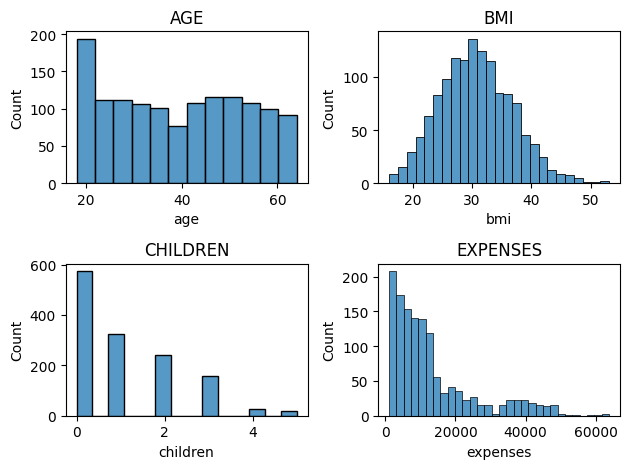

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.subplot(2,2,1)
sns.histplot(df["age"])
plt.title("AGE")

plt.subplot(2,2,2)
sns.histplot(df["bmi"])
plt.title("BMI")

plt.subplot(2,2,3)
sns.histplot(df["children"])
plt.title("CHILDREN")

plt.subplot(2,2,4)
sns.histplot(df["expenses"])
plt.title("EXPENSES")
plt.tight_layout()

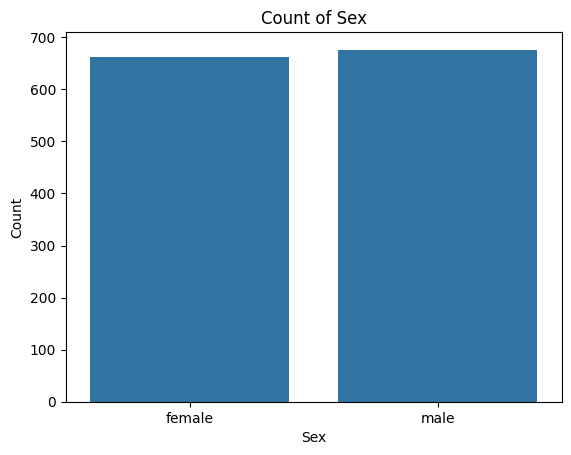

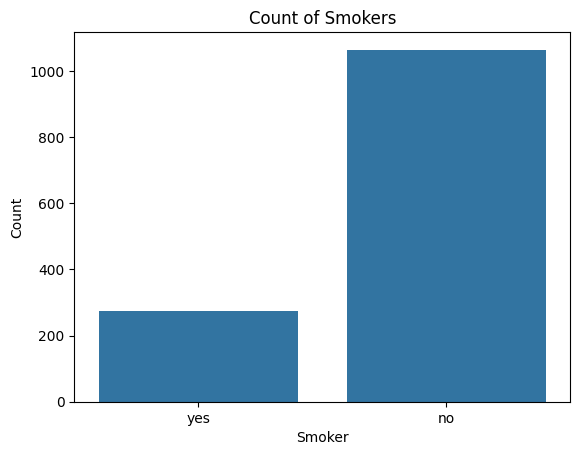

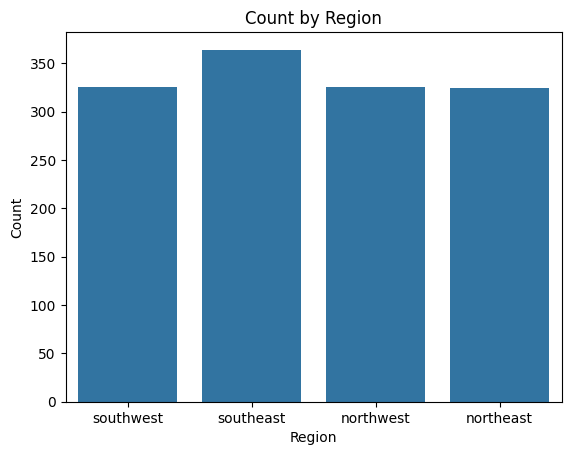

In [55]:

sns.countplot(x="sex", data=df)
plt.title("Count of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

sns.countplot(x="smoker", data=df)
plt.title("Count of Smokers")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.show()

sns.countplot(x="region", data=df)
plt.title("Count by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

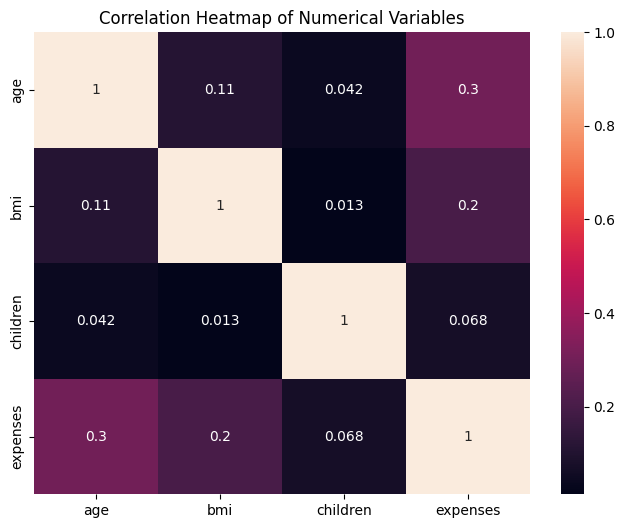

In [62]:
corr_matrix = df[["age", "bmi", "children", "expenses"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [66]:
average=df["expenses"].mean()
print("Average:",average)
max=df["expenses"].max()
print("Maximum:",max)
min=df["expenses"].min()
print("Minimum:",min)
smoker=df.groupby("smoker")["expenses"].mean()
print("group by smoker:",smoker)

Average: 13270.422414050823
Maximum: 63770.43
Minimum: 1121.87
group by smoker: smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


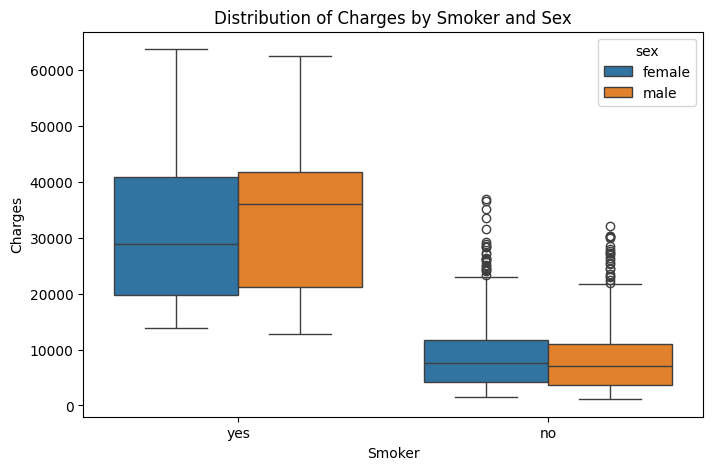

In [68]:
plt.figure(figsize=(8,5))
sns.boxplot(x="smoker", y="expenses", hue="sex", data=df)
plt.title("Distribution of Charges by Smoker and Sex")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()